In [ ]:
# Vector Basics
import numpy as np
import matplotlib.pyplot as plt

# Vectors are just list of numbers
v = np.array([3, 4])
w = np.array([1, 2])

print(f"v = {v}")
print(f"w = {w}")
print(f"v + w = {v + w}") # element-wise addition
print(f"v * w = {v * w}") # element-wise scalar multiplication
print(f"Dot Product v.w = {np.dot(v, w)}") # 3*1 + 4*2 = 11

# The Dot product measures alignement
# v.w = |v| * |w| * cos(0)
# Positive = pointing similar direction
# Negative = pointing opposite direction
# Zero = perpendicular

v = [3 4]
w = [1 2]
v + w = [4 6]
v * w = [3 8]
Dot Product v.w = 11


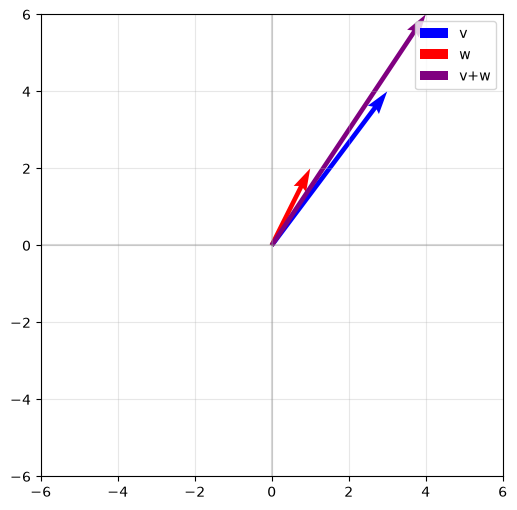

In [13]:
# Visualize Vectors
# Plot vectors to build geometric intuition
from matplotlib.lines import lineStyles


def plot_vector(vectors, colors, labels):
    plt.figure(figsize=(6,6))
    ax=plt.gca()
    ax.axhline(y=0, color='grey', linestyle= '-', alpha=0.3)
    ax.axvline(x=0, color='grey', linestyle= '-', alpha=0.3)

    for vec, color, label in zip(vectors, colors, labels):
        ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=color, label=label, width=0.01)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Define vectors
v = np.array([3, 4])
w = np.array([1, 2])
plot_vector([v, w, v+w], ['blue', 'red', 'purple'], ['v', 'w', 'v+w'])

# v+w forms the diagonal of the parallelogram. This is vector addition geometrically.

In [ ]:
# Matrix Multiplication — The Manual Way
# Matrix multiplication: A (2x3) @ B (3x2) = C (2x2)
A = np.array([[1, 2, 3], 
              [4, 5, 6]]) # Shape: 2 rows, 3 columns
B = np.array([[1, 2],
              [3, 4],
              [5, 6]]) # Shape: 3 rows, 2 columns
# NumPy's built-in
C_numpy = A @ B
print("Numpy result:\n", C_numpy) 
# Calculation 
# 1*1 + 2*3 + 3*5 = 22 
# 1*2 + 2*4 + 3*6 = 28
# 4*1 + 5*3 + 6*5 = 49
# 4*2 + 5*4 + 6*6 = 64

# Manual implementation using nested loops
def matric_multiply_manual(X, Y):
    """Multiply X (m×n) by Y (n×p) to get Z (m×p)"""
    m, n = X.shape
    n_check, p = Y.shape
    assert n == n_check, f"Inner dimensions must match: {n} != {n_check}"
    Z = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            sum_val = 0
            for k in range(n):
                sum_val += X[i, k] * Y[k, j]
            Z[i, j] = sum_val
    return Z

C_manual = matric_multiply_manual(A, B)
print("Manual result:\n", C_manual)
print("Are they equal?", np.allclose(C_manual, C_numpy))

# Why this matters for ML: A neural network layer Y = X @ W does exactly this — 
# every output feature is a weighted combination of input features.

Numpy result:
 [[22 28]
 [49 64]]
Manual result:
 [[22. 28.]
 [49. 64.]]
Are they equal? True


In [ ]:
# Matrix Multiplication as Linear Combination of Columns
# Matrix-vector multiplication: A @ x = weighted sum of A's columns

from unittest import result


A = np.array([[1, 2], 
              [4, 5],
              [7, 8]]) # 3x2 matrix

x = np.array([10, 100]) # 2x1 vector

# Standard result
result_standard = A @ x
print("A @ x =\n", (result_standard)) # 210, 490, 770

# Same result as: column1 * x[0] + column2 * x[1]
result_column_view = A[:, 0] * x[0] + A[:, 1] * x[1]
print ("col1*10 + col2*100 =\n", (result_column_view)) # 210, 490, 770

# Visual proof
print("\nColumn 1 * 10:", A[:, 0] * 10)
print("\nColumn 2 * 100:", A[:, 1] * 100)
print("\nSum:", A[:, 0] * 10 + A[:, 1] * 100)

# THINK: Every linear layer in a neural network does this.
# The columns of W are "templates" - the input x decides how much
# of each template to mix together.
# Internalize this: When a neural network learns, it's finding the right set of column templates

A @ x =
 [210 540 870]
col1*10 + col2*100 =
 [210 540 870]

Column 1 * 10: [10 40 70]

Column 2 * 100: [200 500 800]

Sum: [210 540 870]


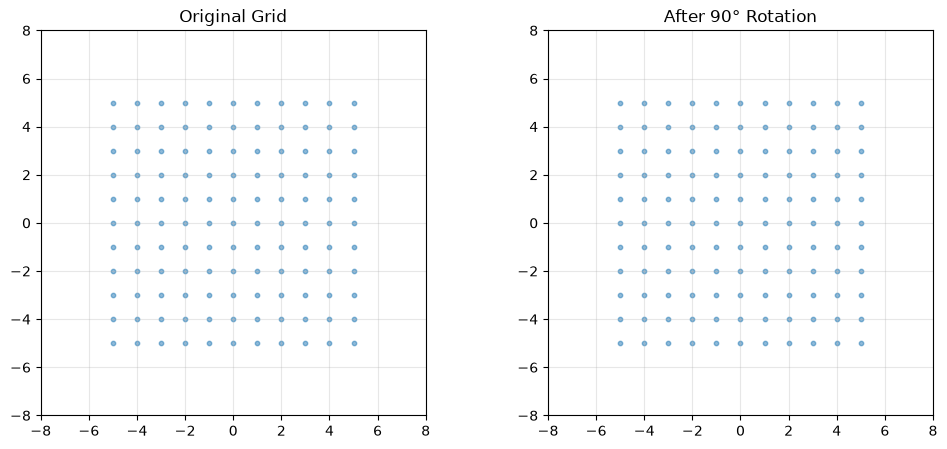

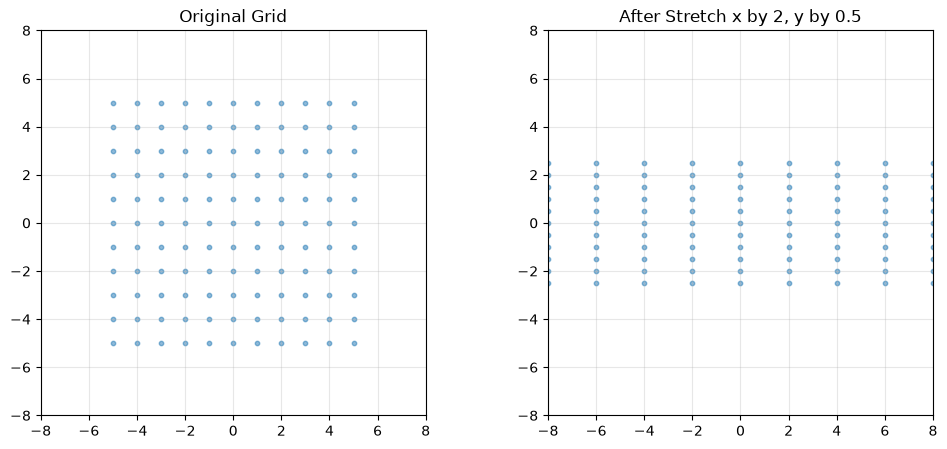

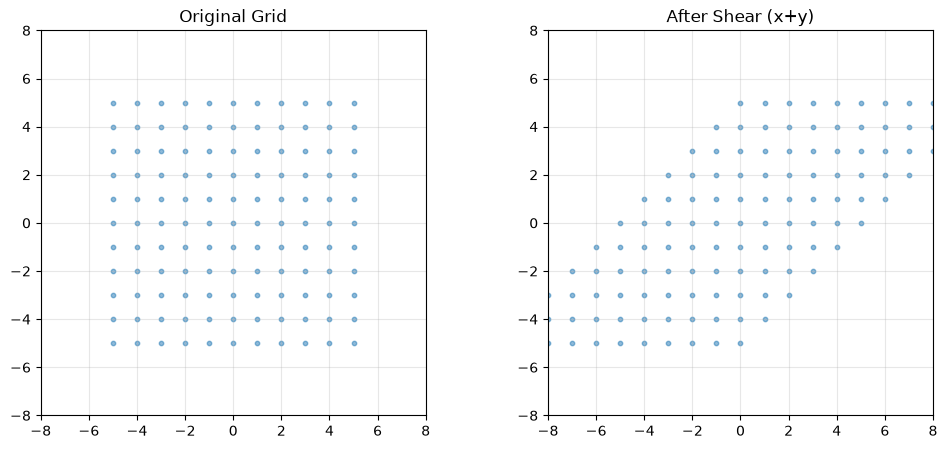

In [24]:
# Matrix Transformations - Rotate and Scale Space
# Create a grid of points and watch how matrices transform them

def plot_transformation(matrix, title):
    # Create a grid of points
    points = []
    for x in range(-5, 6):
        for y in range(-5, 6):
            points.append([x, y])
    points = np.array(points)

    # Apply transformation
    transformed = points @ matrix.T # Each point is a row vector
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    ax1.scatter(points[:, 0], points[:, 1], alpha=0.5, s=10)
    ax1.set_title("Original Grid")
    ax1.set_xlim(-8, 8)
    ax1.set_ylim(-8, 8)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    ax2.scatter(transformed[:, 0], transformed[:, 1], alpha=0.5, s=10)
    ax2.set_title(f"After {title}")
    ax2.set_xlim(-8, 8)
    ax2.set_ylim(-8, 8)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    plt.show()

# Rotation matrix (90 degrees counter-clockwise)
theta = np.pi / 2
rotation = np.array([(np.cos(theta), -np.sin(theta)),
                    (np.sin(theta), np.cos(theta))])
plot_transformation(rotation, "90° Rotation")

# Scaling matrix (stretch x by 2, y by 0.5)
scaling = np.array([(2, 0),
                    (0, 0.5)])
plot_transformation(scaling, "Stretch x by 2, y by 0.5")

# Shear matrix
shear = np.array([(1, 1),
                  (0, 1)])
plot_transformation(shear, "Shear (x+y)")

# Connection to ML: Data augmentation (rotation, scaling) and normalization (whitening) are just matrix transformations. 
# BatchNorm is learning the right scaling matrix.


In [ ]:
    # Eigenvalues and Eigenvectors
    # Eigenvectors are directions that don't change under transformation
    # They only get scaled by their eigenvalue

A = np.array([[2, 1],
                [1, 2]])


eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:\n", A)
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

# Verification: A @ eigenvector (v) = eigenvalue (λ) * eigenvector (v)
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    Av = A @ v
    lam_v = lam * v
    print(f"\nEigenvector {i+1}: {v}")
    print(f"A @ v = {Av}")
    print(f"λ * v = {lam_v}")
    print(f"Are they equal? {np.allclose(Av, lam_v)}")

# Intuition: If you apply A to its eigenvector, the direction doesn't change,
# only the magnitude. These are the "natural axes" of the transformation.

# Why this matters: PCA is built on eigenvectors of the covariance matrix. 
# The eigenvectors with largest eigenvalues are the directions of maximum variance — the most important features.

Matrix A:
 [[2 1]
 [1 2]]
Eigenvalues:
 [3. 1.]
Eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Eigenvector 1: [0.70710678 0.70710678]
A @ v = [2.12132034 2.12132034]
λ * v = [2.12132034 2.12132034]
Are they equal? True

Eigenvector 2: [-0.70710678  0.70710678]
A @ v = [-0.70710678  0.70710678]
λ * v = [-0.70710678  0.70710678]
Are they equal? True


In [48]:
# Joint, Marginal, Conditional Probability

# Let's model: Weather (Sunny, Rainy) and Activity (Walk, Read)

# Joint probability table: P(Weather, Activity)
#              Walk    Read
# Sunny        0.4     0.2      → P(Sunny) = 0.6
# Rainy        0.1     0.3      → P(Rainy) = 0.4
#               ↓       ↓
#          P(Walk)=0.5  P(Read)=0.5

joint = np.array([[0.4, 0.2],
                  [0.1, 0.3]])

print("Joint Probability P(Weather, Activity):")
print("Rows: Sunny, Rainy | Columns: Walk, Read")
print(joint)
print(f"\nSum of all probabilities {joint.sum()}")

# Marginal probabilities: sum over one variable
p_weather = joint.sum(axis=1)
p_activity = joint.sum(axis=0)

print(f"\nMarginal P(Weather): Sunny={p_weather[0]:.1f}, Rainy={p_weather[1]:.1f}")
print(f"\nMarginal P(Activity): Walk={p_activity[0]:.1f}, Read={p_activity[1]:.1f}")

# Conditional probability: P(Activity|Weather)
# P(Walk|Sunny) = P(Walk, Sunny) / P(Sunny)
p_walk_given_sunny = joint[0, 0] / p_weather[0]
print(f"\nP(Walk | Sunny) = {p_walk_given_sunny:.3f}")

p_read_given_rainy = joint[1, 1] / p_weather[1]
print(f"P(Read | Rainy) = {p_read_given_rainy:.3f}")

# Bayes' Theorem: P(Sunny | Walk) = P(Walk | Sunny) * P(Sunny) / P(Walk)
p_sunny_given_walk = p_walk_given_sunny * p_weather[0] / p_activity[0]
print(f"\nBayes: P(Sunny | Walk) = {p_sunny_given_walk:.3f}")
# Verify directly from table
print(f"Direct: P(Sunny, Walk)/P(Walk) = {joint[0,0]}/{p_activity[0]} = {joint[0,0]/p_activity[0]:.3f}")

# Connection to your product: Your assistant will constantly compute P(user_is_wrong | what_they_said). 
# Bayes' Theorem is how you update beliefs with evidence.

Joint Probability P(Weather, Activity):
Rows: Sunny, Rainy | Columns: Walk, Read
[[0.4 0.2]
 [0.1 0.3]]

Sum of all probabilities 1.0

Marginal P(Weather): Sunny=0.6, Rainy=0.4

Marginal P(Activity): Walk=0.5, Read=0.5

P(Walk | Sunny) = 0.667
P(Read | Rainy) = 0.750

Bayes: P(Sunny | Walk) = 0.800
Direct: P(Sunny, Walk)/P(Walk) = 0.4/0.5 = 0.800


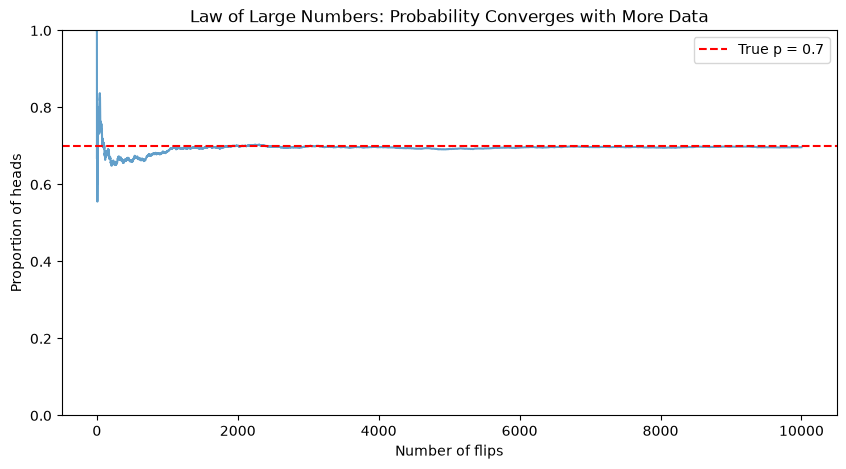

After 10 flips: 0.600
After 100 flips: 0.700
After 1000 flips: 0.686
After 10000 flips: 0.697


In [ ]:
# Sampling and the Law of Large Numbers
# Flip a biased coin many times and watch probability converge

n_flips = 10000
p_heads_true = 0.7
flips = np.random.random(n_flips) < p_heads_true # True = heads

cumulative_heads = np.cumsum(flips)
cumulative_prob = cumulative_heads / np.arange(1, n_flips + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_prob, alpha=0.7)
plt.axhline(y=p_heads_true, color='red', linestyle='--', label=f'True p = {p_heads_true}')
plt.xlabel('Number of flips')
plt.ylabel('Proportion of heads')
plt.title('Law of Large Numbers: Probability Converges with More Data')
plt.legend()
plt.ylim(0, 1)
plt.show()

print(f"After 10 flips: {cumulative_prob[9]:.3f}")
print(f"After 100 flips: {cumulative_prob[99]:.3f}")
print(f"After 1000 flips: {cumulative_prob[999]:.3f}")
print(f"After 10000 flips: {cumulative_prob[9999]:.3f}")

# ML lesson: Your model's accuracy on 10 test examples is unreliable. 
# On 10,000, it's trustworthy. This is why we need large test sets.


In [60]:
# Entropy from Scratch

def entropy(p):
    """
    H(p) = -Σ p(x) * log2(p(x))

    Measures average surprise (in bits) of a distribution
    Fair coin = 1 bit (Maximum uncertainty)
    Biased coin (p=0.99): ~0.08 bits (almost always heads, low surprise)
    """
    p = np.asarray(p)
    # Avoid log(0) - events with zero probability contribute zero entropy
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

# Fair coin (natural entropy for 2 outcomes)
fair_coin = np.array([0.5, 0.5])
print(f"Fair coin entropy: {entropy(fair_coin):.4f} bits")

very_biased = np.array([0.99, 0.01])
print(f"Very biased coin entropy: {entropy(very_biased):.4f} bits")

# Deterministic (no uncertainty)
certain = np.array([1.0, 0.0])
print(f"Deterministic entropy: {entropy(certain):.4f} bits")

# Dice roll (uniform over 6 outcomes)
dice = np.ones(6) / 6
print(f"Fair dice entropy: {entropy(dice):.4f} bits")
print(f"log2(6) = {np.log2(6):.4f} bits")

# Connection to ML: A classifier that outputs [0.99, 0.01] is highly confident (low entropy).
# One that outputs [0.5, 0.5] is uncertain. You want confident, correct predictions.


Fair coin entropy: 1.0000 bits
Very biased coin entropy: 0.0808 bits
Deterministic entropy: -0.0000 bits
Fair dice entropy: 2.5850 bits
log2(6) = 2.5850 bits


In [65]:
# Cross-Entropy - The Most Important Loss Function

def cross_entropy(p_true, q_pred):
    """
    H(p, q) = -Σ p(x) * log2(q(x))

    p_true = true distribution (one-hot for classification)
    q_pred = predicted distribution (model output after softmax)

    Measures how many bits needed to encode p using code optimized for q
    """
    p_true = np.asarray(p_true)
    q_pred = np.asarray(q_pred)
    # only consider events where p_true > 0
    mask = p_true > 0
    return -np.sum(p_true[mask] * np.log2(q_pred[mask]))

# Example: 3-class classification
# True class is 1 (index 1)
y_true = np.array([0.0, 1.0, 0.0])

# Model A: confident and correct
y_pred_good = np.array([0.1, 0.8, 0.1])
loss_good = cross_entropy(y_true, y_pred_good)
print(f"Good Prediction: {y_pred_good}: CE loss = {loss_good:.4f} bits")

# Model B: confident but wrong
y_pred_bad = np.array([0.8, 0.1, 0.1])
loss_bad = cross_entropy(y_true, y_pred_bad)
print(f"Bad Prediction: {y_pred_bad}: CE loss = {loss_bad:.4f} bits")

# Model C: uncertain
y_pred_uncertain = np.array([0.33, 0.34, 0.33])
loss_uncertain = cross_entropy(y_true, y_pred_uncertain)
print(f"Uncertain Prediction: {y_pred_uncertain}: CE loss = {loss_uncertain:.4f} bits")

print("\nInsight: Cross-entropy penalizes confident wrong predictions heavily!")
print(f"Bad/Good ratio: {loss_bad/loss_good:.2f}x worse")

# Cross-entropy heavily punishes models that are sure and wrong. 
# That’s intentional: wrong-and-confident predictions are dangerous, so the loss should be large.

# Bottom line: the ratio measures prediction quality, not data quality. 
# Higher ratio = the bad prediction is much more harshly penalized than the good one.


Good Prediction: [0.1 0.8 0.1]: CE loss = 0.3219 bits
Bad Prediction: [0.8 0.1 0.1]: CE loss = 3.3219 bits
Uncertain Prediction: [0.33 0.34 0.33]: CE loss = 1.5564 bits

Insight: Cross-entropy penalizes confident wrong predictions heavily!
Bad/Good ratio: 10.32x worse


In [71]:
# KL Divergence — How Different Are Two Distributions?

def kl_divergence(p, q):
    """
    D_KL(p || q) = Σ p(x) * log(p(x) / q(x))

    Measures how much information is lost when Q is used to approximate P.
    Always >= 0. Zero only when p = q.
    NOT symmetric: D_KL(p || q) ≠ D_KL(q || p)
    """
    p = np.asarray(p)
    q = np.asarray(q)
    # only consider where p > 0
    mask = p > 0
    return np.sum(p[mask] * np.log2(p[mask] / q[mask]))

# True distribution
P = np.array([0.7, 0.2, 0.1])

# Two approximations
Q1 = np.array([0.6, 0.25, 0.15]) # Close to P
Q2 = np.array([0.1, 0.1, 0.8])  # Very different

print(f"D_KL(P || Q1) = {kl_divergence(P, Q1):.4f} (close approximation)")
print(f"D_KL(P || Q2) = {kl_divergence(P, Q2):.4f} (poor approximation)")

# Non-symmetry demonstration
print(f"\nD_KL(Q2 || P) = {kl_divergence(Q2, P):.4f} (different value!)")

# Relationship to cross-entropy: CE = H(P) + D_KL(P || Q)
ce = cross_entropy(P, Q1)
h_p = entropy(P)
kl = kl_divergence(P, Q1)
print(f"\nCross-Entropy: {ce:.4f}")
print(f"Entropy(P) + KL(P||Q1): {h_p + kl:.4f}")
print(f"They match! CE = H(P) + D_KL(P||Q1)")

# Why this matters: Minimizing cross-entropy loss is equivalent to minimizing KL divergence. 
# The model is trying to make its predicted distribution match the true distribution.

D_KL(P || Q1) = 0.0328 (close approximation)
D_KL(P || Q2) = 1.8651 (poor approximation)

D_KL(Q2 || P) = 2.0193 (different value!)

Cross-Entropy: 1.1896
Entropy(P) + KL(P||Q1): 1.1896
They match! CE = H(P) + D_KL(P||Q1)


In [ ]:
summary = """
DAY 1 KEY INSIGHTS:

1. LINEAR ALGEBRA:
   - Matrix multiplication = linear combination of columns
   - Every NN layer: Y = X @ W is mixing input features using W's columns as templates
   - Eigenvectors point in directions that don't change under transformation
   - PCA finds eigenvectors of covariance = directions of maximum variance

2. PROBABILITY:
   - Joint P(A,B) → Marginal P(A) → Conditional P(A|B)
   - Bayes: P(A|B) = P(B|A) * P(A) / P(B)
   - This is how you update beliefs with evidence
   - Your assistant will constantly compute P(needs_correction | utterance)

3. INFORMATION THEORY:
   - Entropy = average surprise (bits needed to encode)
   - Cross-entropy = bits needed if you use wrong distribution
   - KL divergence = penalty for using Q instead of P
   - Minimizing cross-entropy = making predictions match truth

"""
print(summary)